# KG-Commit v4 — Which subgraph is best?

**Online (prequential) evaluation of alternative structural subgraphs for
commit-level Just-In-Time defect prediction on Apache Groovy (ApacheJIT,
8,059 labelled commits).**

Our final methodology uses an **AST subgraph with a delta / difference graph** as
the structural layer of the knowledge graph. This notebook answers the research
question *"is AST actually the best structural subgraph?"* by **replacing** the
AST layer with each standard alternative and evaluating under one **identical
online protocol**, **before** the semantic-text (CSTG) layer is added.

### The one channel a subgraph feeds
A structural layer influences prediction through exactly one signal: per-commit
**change-tokens** `"{edge}:{type}"` with `edge ∈ {ADDS, REMOVES, UPDATES, MOVES}`,
emitted by the online delta-growth engine. These tokens become the structural
TF-IDF stream (**T**) and the typed hubs of the Personalized-PageRank graph (**P**).

Every variant shares the **same core** — JIT metrics (**M**), relational priors
(**R**), PPR (**P**) — the same classifier, and the same warmup/block schedule.
Text features (**X**) and the semantic-text subgraph (**G**) are **disabled**, so
the *only* thing that varies is the structural subgraph. Headline metric is the
**Fusion** model `= M + T + R + P`.

### Variants
| id | structural layer | Neo4j label |
|----|------------------|-------------|
| V1 | none (core only) | — |
| V2a | CFG (control-flow) | `:CFGNode` |
| V2b | DFG (def-use data-flow) | `:DFGNode` |
| V2c | PDG/CPG (program dependence) | `:PDGNode` |
| V2d | Token / statement sequence | `:SEQNode` |
| V3 | **AST (incumbent)** | `:ASTNode` |


In [1]:
import json, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
%matplotlib inline

OUT = Path.cwd()
while not (OUT / "outputs").exists() and OUT != OUT.parent:
    OUT = OUT.parent
OUT = OUT / "outputs"
res   = pickle.load(open(OUT / "subgraph_rq_results.pkl", "rb"))
stats = json.load(open(OUT / "subgraph_layer_stats.json"))
FIG   = OUT / "figures" / "v4"

ORDER = ["V1_none","V2a_cfg","V2b_dfg","V2c_pdg","V2d_seq","V3_ast"]
NAME  = {"V1_none":"Core (no subgraph)","V2a_cfg":"CFG","V2b_dfg":"DFG",
         "V2c_pdg":"PDG/CPG","V2d_seq":"Token-seq","V3_ast":"AST"}
meta  = res["V3_ast"]
print(f"stream: {meta['warmup']+meta['n_eval']} commits | warmup {meta['warmup']} |"
      f" scored online {meta['n_eval']} | stream bug-rate {meta['stream_bug']:.3f}")

stream: 8059 commits | warmup 3223 | scored online 4836 | stream bug-rate 0.245


## 1. Structural layers materialised in the KG

Each alternative layer is built by the same online delta-growth engine (`build_subgraph_online_kg.py`) over the 8,059-commit stream, using one shared uniform differ (`subgraph_diff.py`). All four coexist with the AST layer under distinct node labels.

In [2]:
SKEY = {"V3_ast":"ast","V2a_cfg":"cfg","V2b_dfg":"dfg","V2c_pdg":"pdg","V2d_seq":"seq"}
rows = []
for v in ["V3_ast","V2a_cfg","V2b_dfg","V2c_pdg","V2d_seq"]:
    s = stats[SKEY[v]]
    rows.append([NAME[v], s["nodes"], s["delta_total"], s["n_node_types"],
                 s["n_token_types"], s["commits_with_tokens"]])
layers = pd.DataFrame(rows, columns=["Layer","Nodes","Delta-edges","Node types",
                                     "Token types","Commits w/ tokens"])
display(layers.style.format({"Nodes":"{:,}","Delta-edges":"{:,}",
                             "Commits w/ tokens":"{:,}"}).hide(axis="index"))

Layer,Nodes,Delta-edges,Node types,Token types,Commits w/ tokens
AST,"3,699,439","3,614,922",136,314,"7,523"
CFG,"372,488","408,301",18,53,"6,194"
DFG,"469,662","648,553",7,27,"6,066"
PDG/CPG,"372,488","411,869",18,63,"6,261"
Token-seq,"257,708","293,287",16,47,"6,011"


## 2. Online prequential results

Fusion `= M+T+R+P`; `T-only` isolates the subgraph's change-tokens alone; `P-only` is PPR alone. **X and G are off.** Best per column in **bold**.

In [3]:
def rowf(v):
    F = res[v]["Fusion"]
    return {"Subgraph":NAME[v], "#tok":res[v]["n_token_types"],
            "PR-AUC":F["PR_AUC"], "ROC-AUC":F["ROC_AUC"], "F1-online":F["F1_online"],
            "F1@.5":F["F1"], "MCC":F["MCC"], "Brier":F["Brier"],
            "T-only PR":res[v]["T_only"]["PR_AUC"], "P-only PR":res[v]["P_only"]["PR_AUC"]}
df = pd.DataFrame([rowf(v) for v in ORDER])
hi = ["PR-AUC","ROC-AUC","F1-online","F1@.5","MCC"]
sty = (df.style.hide(axis="index")
       .format({c:"{:.3f}" for c in ["PR-AUC","ROC-AUC","F1-online","F1@.5","MCC",
                                     "Brier","T-only PR","P-only PR"]})
       .highlight_max(subset=hi, color="#d5efdf")
       .highlight_min(subset=["Brier"], color="#d5efdf"))
sty

Subgraph,#tok,PR-AUC,ROC-AUC,F1-online,F1@.5,MCC,Brier,T-only PR,P-only PR
Core (no subgraph),0,0.564,0.805,0.560,0.541,0.376,0.246,0.204,0.439
CFG,53,0.595,0.820,0.583,0.556,0.397,0.234,0.461,0.379
DFG,27,0.594,0.819,0.590,0.556,0.398,0.236,0.469,0.367
PDG/CPG,63,0.595,0.820,0.585,0.555,0.396,0.235,0.464,0.378
Token-seq,47,0.587,0.816,0.577,0.549,0.387,0.235,0.432,0.377
AST,314,0.615,0.826,0.607,0.557,0.400,0.231,0.488,0.361


**Live headline chart** — Fusion PR-AUC by structural subgraph (AST = bold accent):

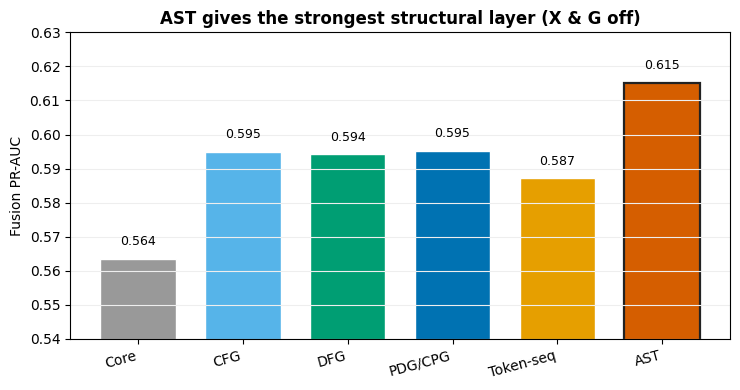

In [4]:
COLOR = {"V1_none":"#999999","V2a_cfg":"#56B4E9","V2b_dfg":"#009E73",
         "V2c_pdg":"#0072B2","V2d_seq":"#E69F00","V3_ast":"#D55E00"}
fig, ax = plt.subplots(figsize=(7.5,4))
vals = [res[v]["Fusion"]["PR_AUC"] for v in ORDER]
bars = ax.bar([NAME[v].replace(" (no subgraph)","") for v in ORDER], vals,
              color=[COLOR[v] for v in ORDER], edgecolor="white", width=0.72)
bars[-1].set_edgecolor("#222"); bars[-1].set_linewidth(1.6)
for b,val in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, val+0.003, f"{val:.3f}",
                                     ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.54,0.63); ax.set_ylabel("Fusion PR-AUC"); ax.grid(axis="y",color="#eee")
ax.set_title("AST gives the strongest structural layer (X & G off)", weight="bold")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

## 3. Publication figures

Rendered by `inference/make_subgraph_figures.py` (Okabe–Ito colourblind-safe palette; PDF versions live in `outputs/figures/v4/` for the paper).

Fusion metrics by subgraph


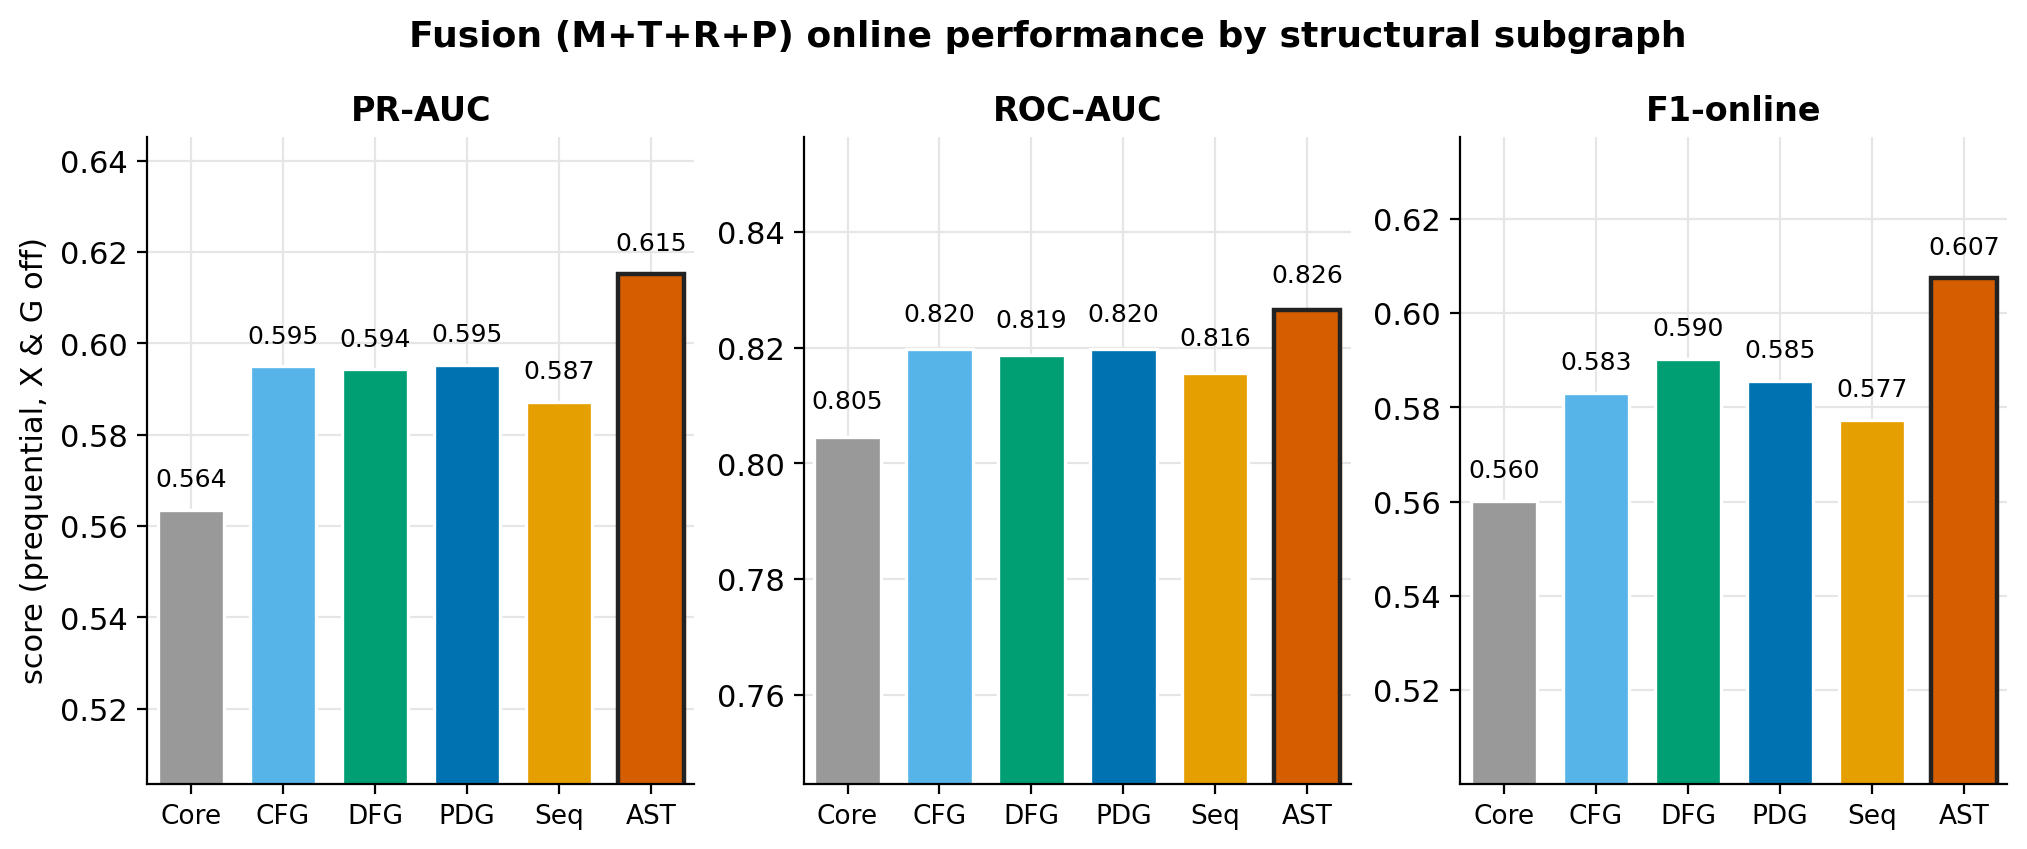

Isolated structural signal (T-only)


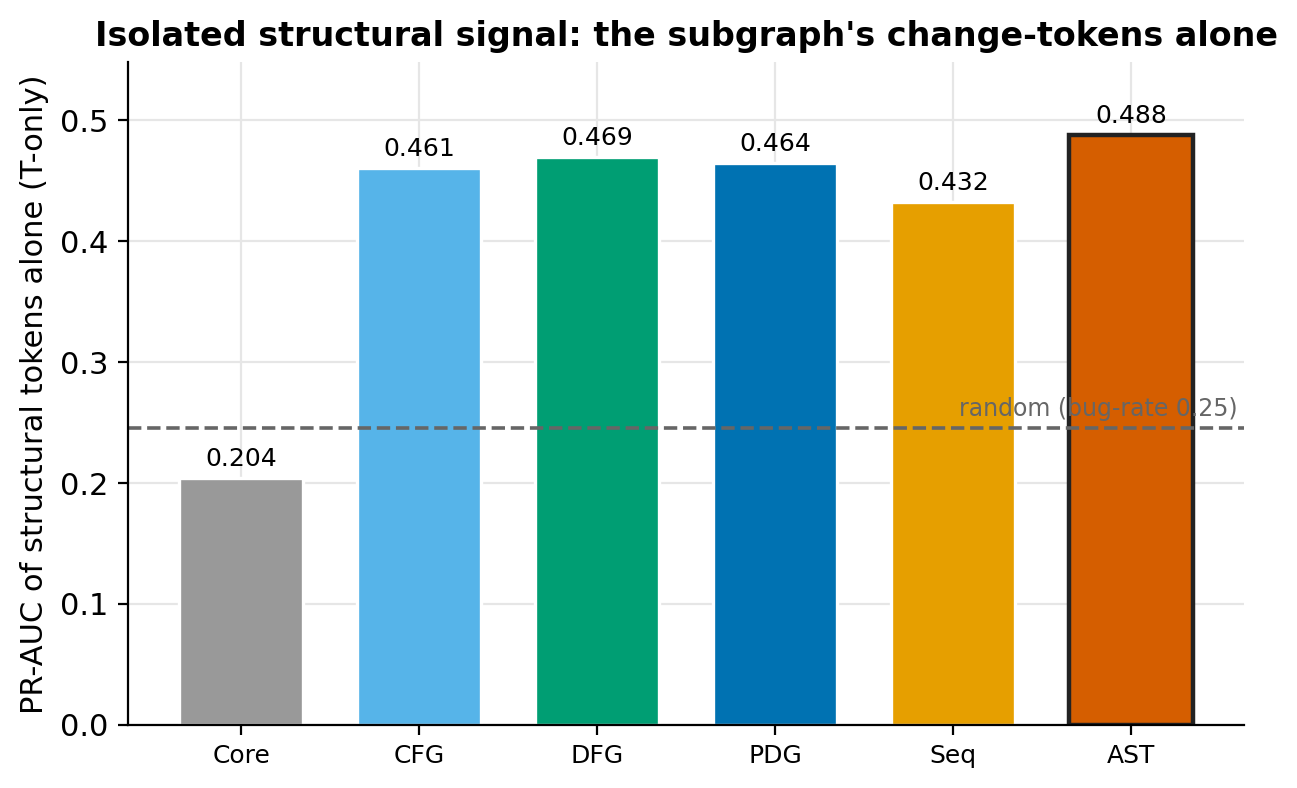

Vocabulary richness -> signal


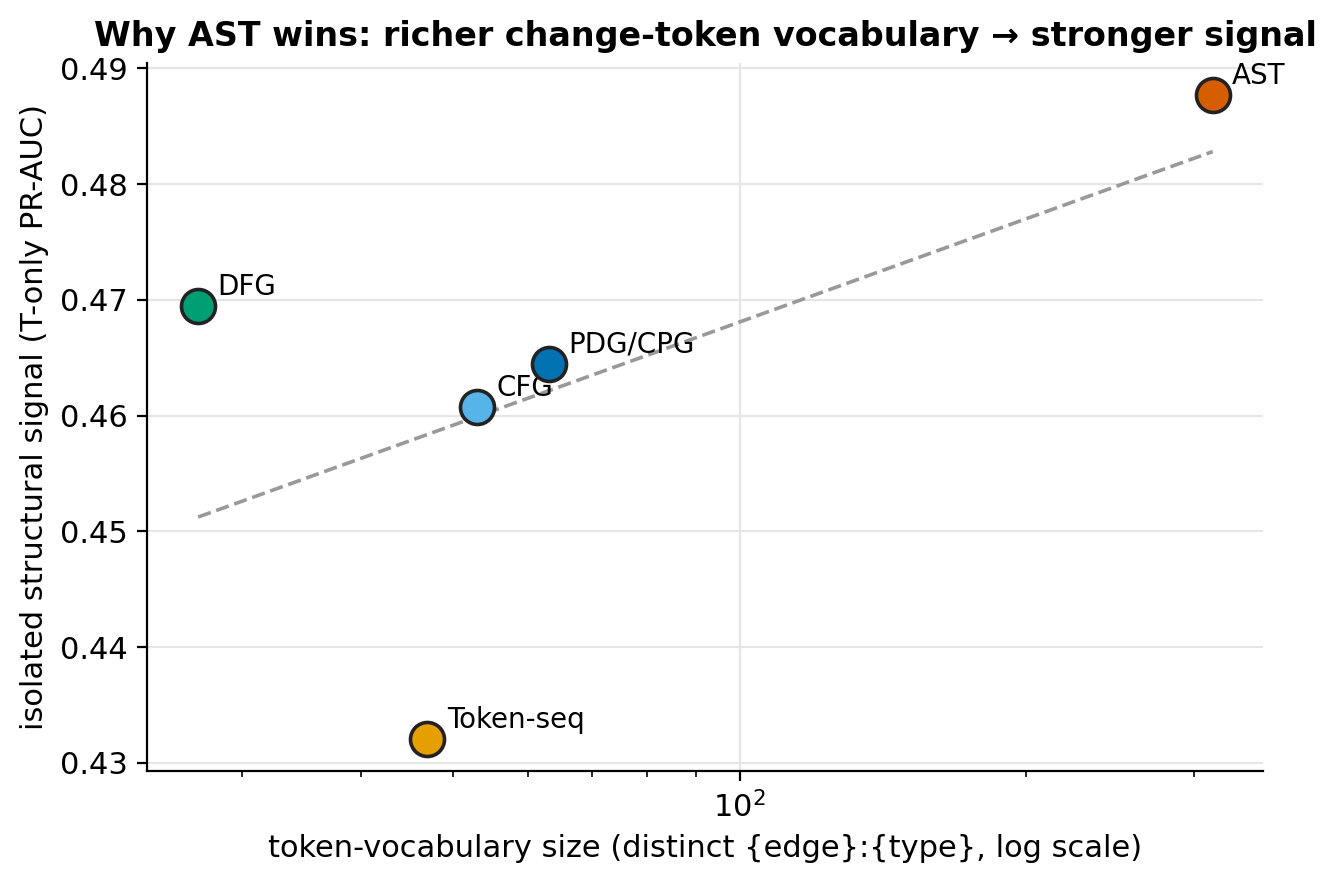

Rolling PR-AUC over the stream


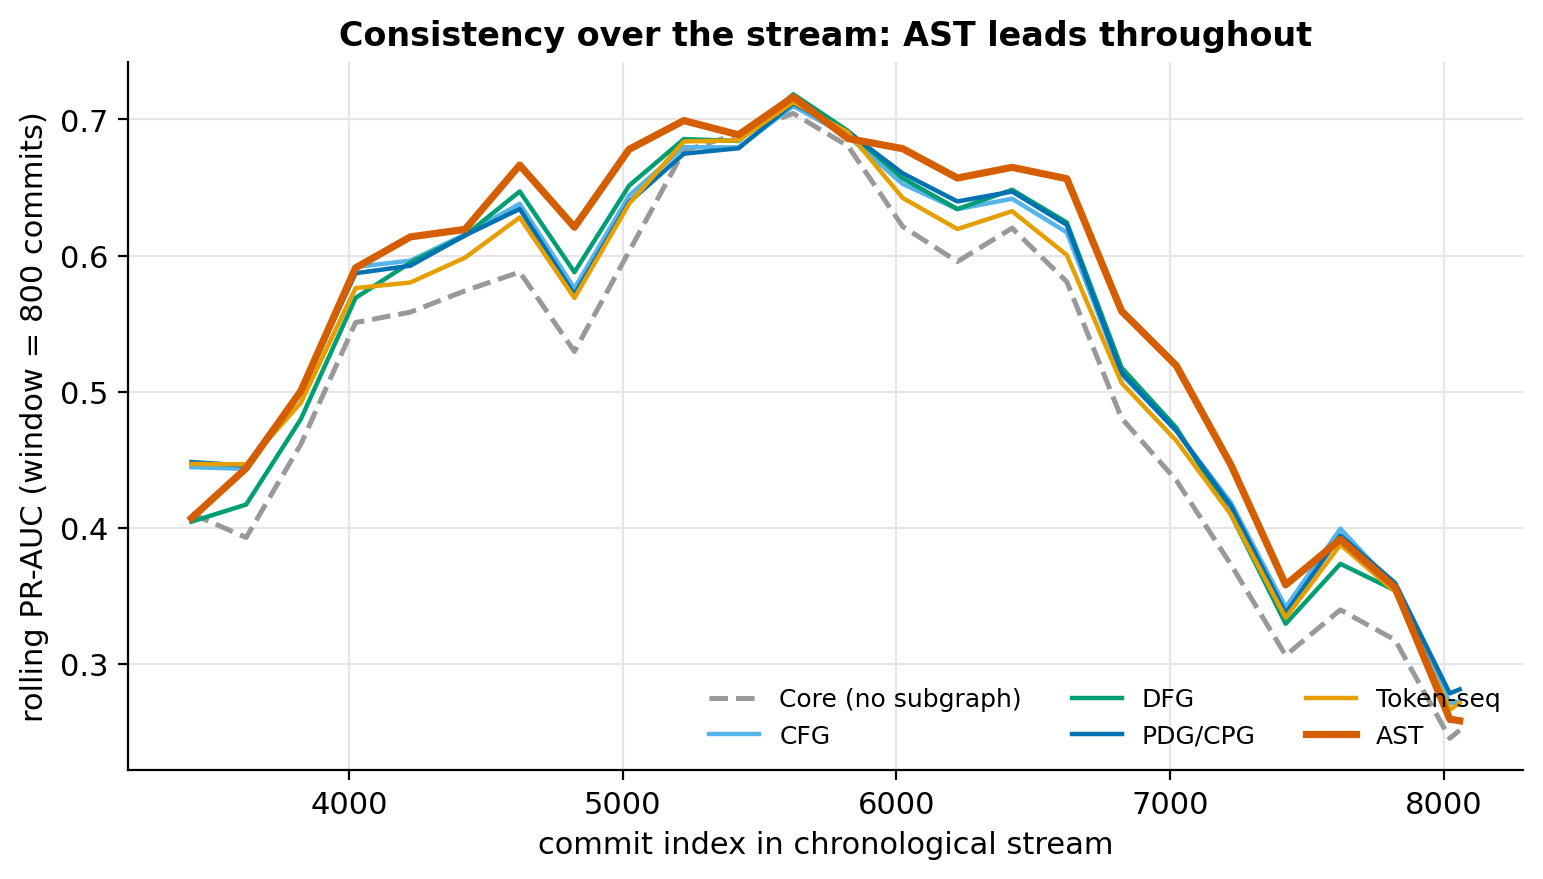

Per-layer graph scale


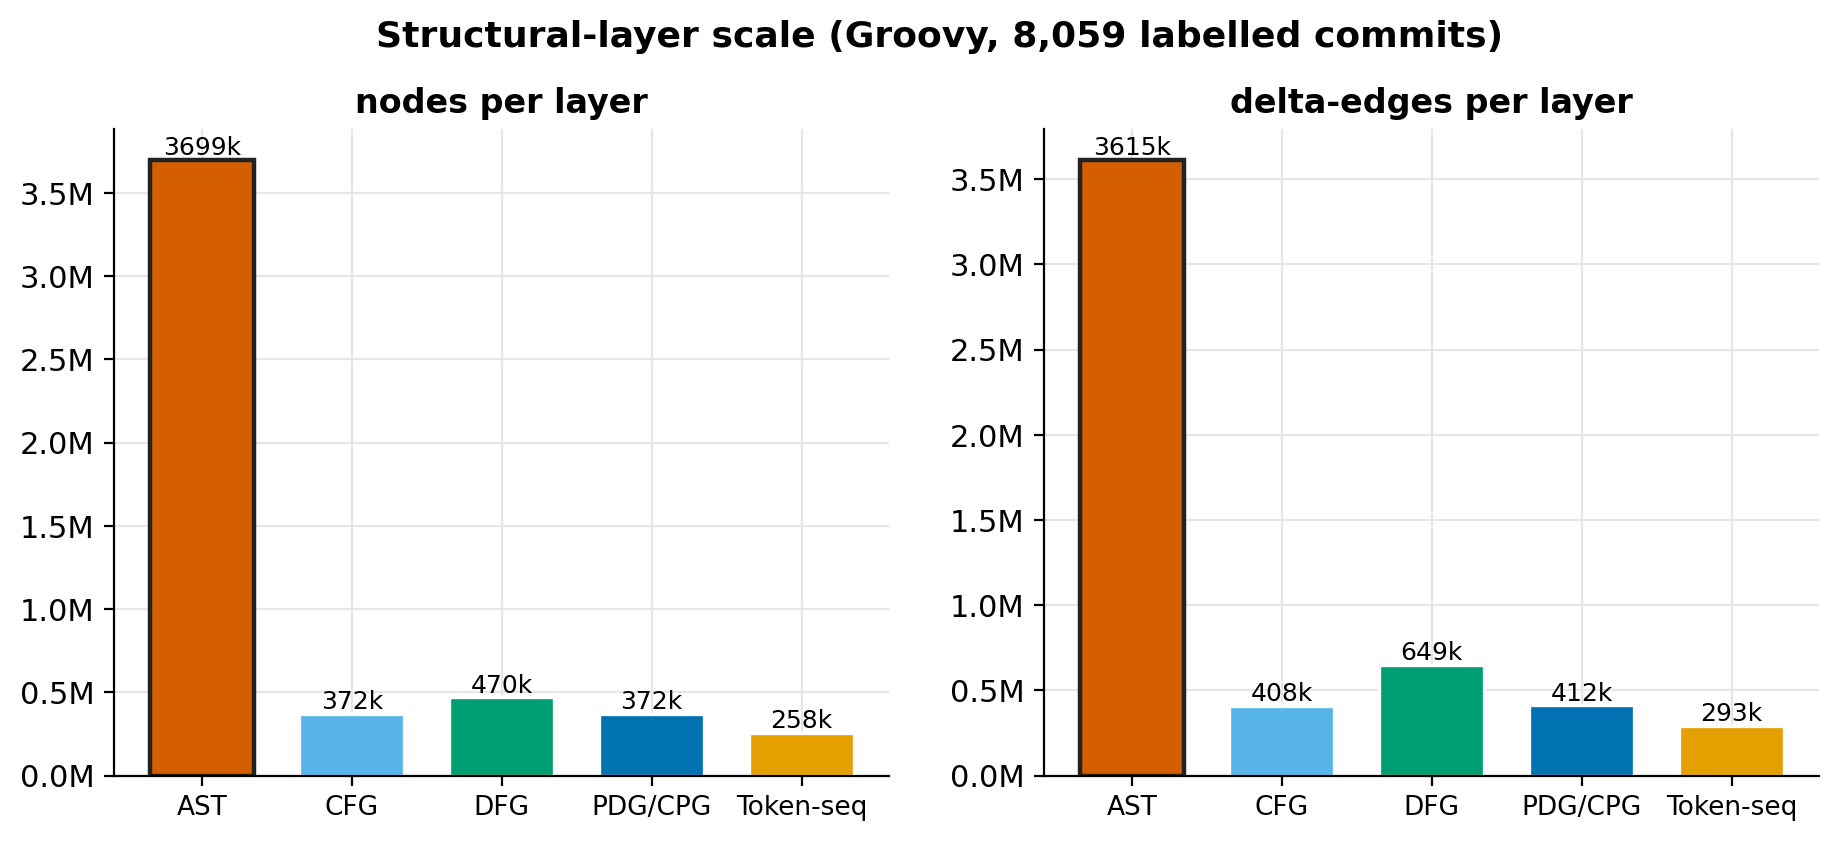

In [5]:
for name,cap in [("fig_fusion_metrics","Fusion metrics by subgraph"),
                 ("fig_tonly_signal","Isolated structural signal (T-only)"),
                 ("fig_vocab_scatter","Vocabulary richness -> signal"),
                 ("fig_trajectory","Rolling PR-AUC over the stream"),
                 ("fig_layer_sizes","Per-layer graph scale")]:
    print(cap); display(Image(filename=str(FIG / f"{name}.png")))

## 4. Per-inference-method comparison (not just Fusion)

We do not stop at the Fusion model: we run **every inference method separately on
each subgraph** and compare. Two methods are **subgraph-independent references**
(they never touch the structural tokens) and four are **subgraph-dependent**:

| method | uses | subgraph-dependent? |
|---|---|---|
| **M** JIT metrics (LR) | 12 change metrics | no |
| **R** Relational priors (wvRN) | file/dev/global bug-rates | no |
| **T** Structural TF-IDF | change-tokens | **yes** |
| **P** Personalized PageRank | typed token hubs | **yes** |
| **E** KG embedding (SVD/LSA) | commit×hub incidence | **yes** |
| **Fusion** | M+T+R+P | **yes** |

Each is evaluated under the identical online prequential protocol.

In [6]:
MO = ["M","R","T","P","E","Fusion"]
MN = {"M":"JIT metrics (M)","R":"Relational priors (R)","T":"Structural TF-IDF (T)",
      "P":"Personalized PageRank (P)","E":"KG embedding / SVD (E)","Fusion":"Fusion (M+T+R+P)"}
STRUCT = {"T","P","E","Fusion"}
def pm_table(metric):
    rows = {MN[m]:{NAME[v]:res[v]["methods"][m][metric] for v in ORDER} for m in MO}
    return pd.DataFrame(rows).T[[NAME[v] for v in ORDER]]
prm = pm_table("PR_AUC")
def hi_struct(row):
    # bold the best variant only for subgraph-dependent methods
    dep = any(k in row.name for k in ["TF-IDF","PageRank","embedding","Fusion"])
    mx = row.max() if dep else None
    return ["font-weight:bold;background:#d5efdf" if (dep and v==mx) else "" for v in row]
display(prm.style.format("{:.3f}").apply(hi_struct, axis=1)
        .set_caption("PR-AUC by inference method (rows) x subgraph (cols); "
                     "best variant per subgraph-dependent method in bold"))

,Core (no subgraph),CFG,DFG,PDG/CPG,Token-seq,AST
JIT metrics (M),0.398,0.398,0.398,0.398,0.398,0.398
Relational priors (R),0.460,0.460,0.460,0.460,0.460,0.460
Structural TF-IDF (T),0.204,0.461,0.469,0.464,0.432,0.488
Personalized PageRank (P),0.439,0.379,0.367,0.378,0.377,0.361
KG embedding / SVD (E),0.402,0.469,0.494,0.461,0.450,0.421
Fusion (M+T+R+P),0.564,0.595,0.594,0.595,0.587,0.615


**Heatmap** (PR-AUC) — orange ring marks the best subgraph for each method; and the four KG-native methods as grouped bars:

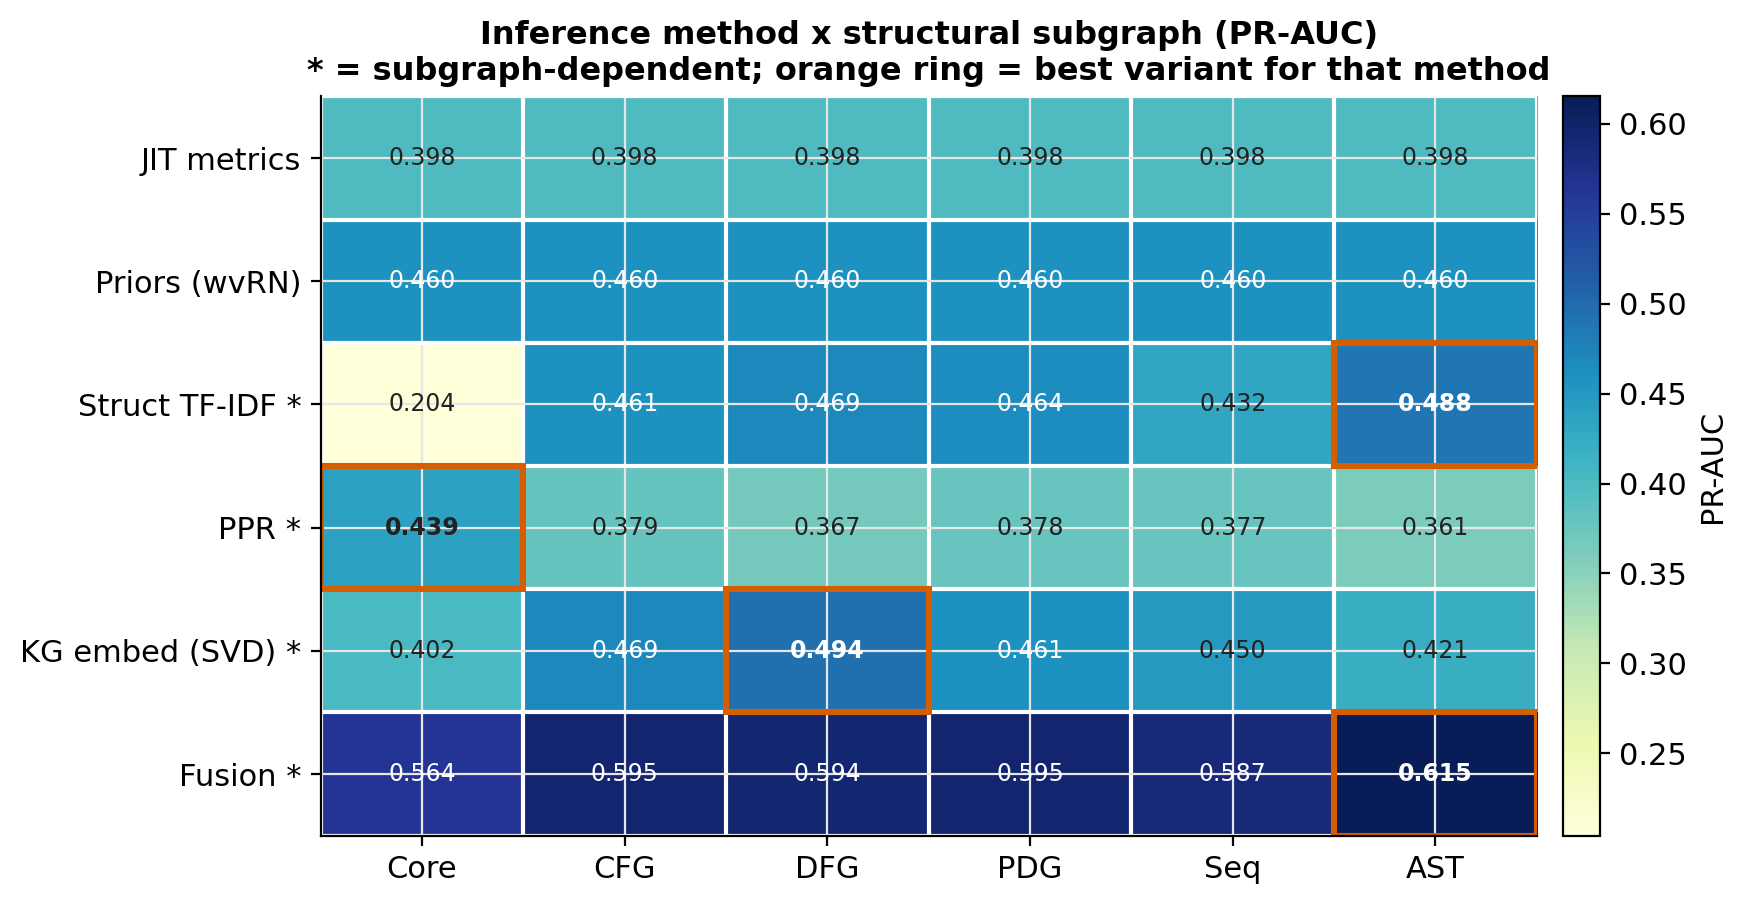

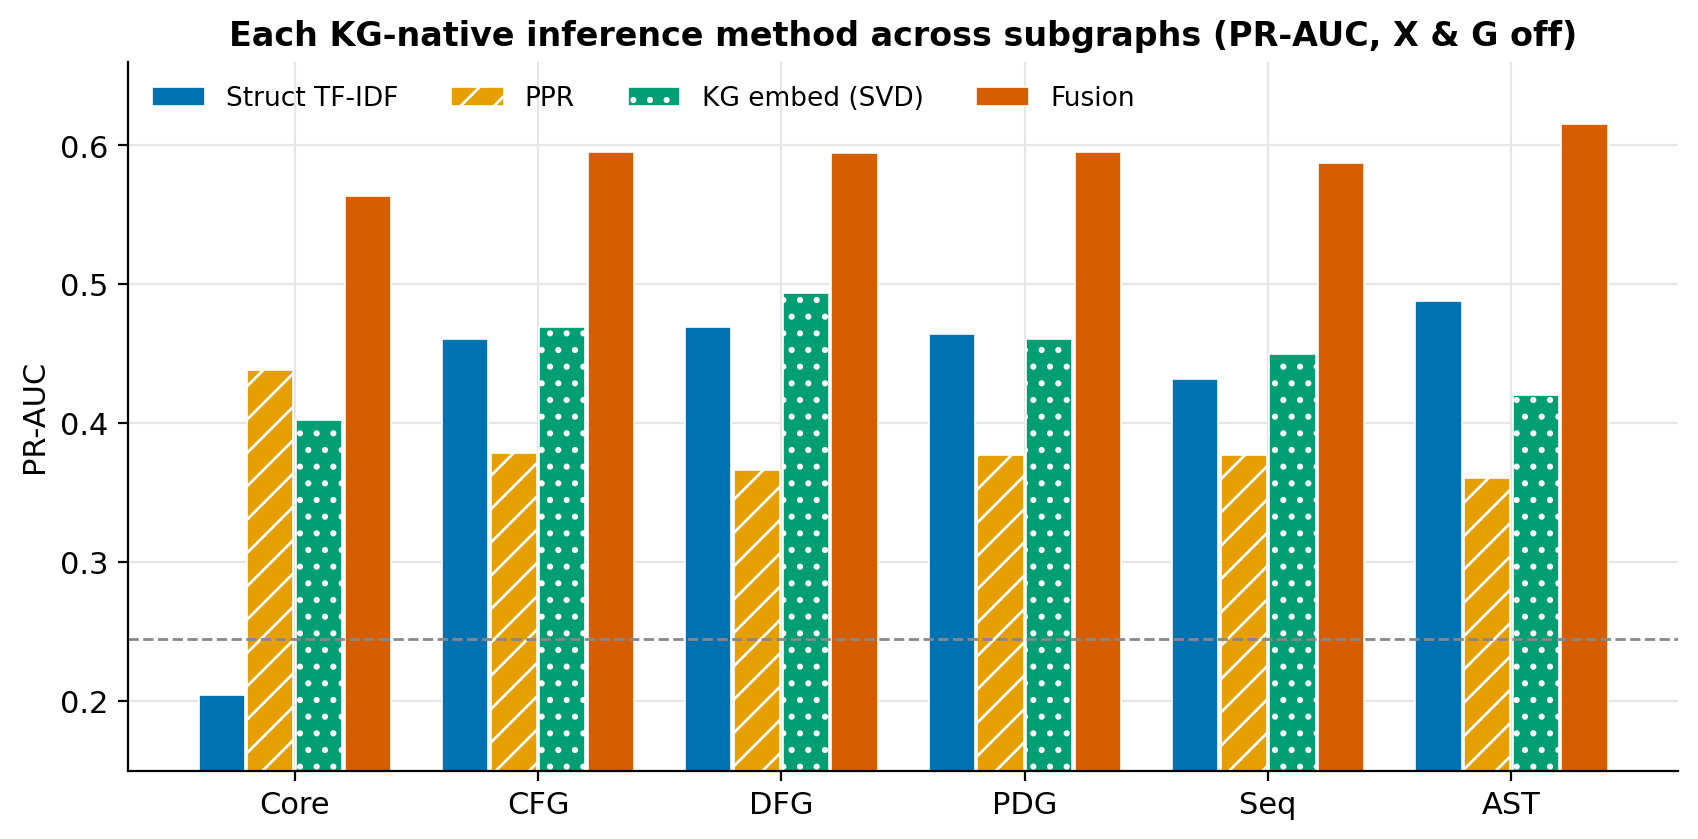

In [7]:
display(Image(filename=str(FIG / "fig_permethod_heatmap.png")))
display(Image(filename=str(FIG / "fig_permethod_bars.png")))

### What the per-method view reveals

* **The two references are flat** across subgraphs (M = 0.398, R = 0.460 PR-AUC),
  confirming they do not use structural information — a sanity check on the setup.
* **Structural TF-IDF (T)** — the most direct use of the change-tokens — is
  **best with AST** (0.488), the cleanest expression of AST's advantage.
* **PPR (P)** is actually **best with _no_ subgraph** (Core 0.439): adding typed
  token hubs dilutes the file/developer relational random walk rather than helping
  it. PPR's signal is relational, not structural.
* **KG embedding (E)** is **best with DFG** (0.494), *above* AST (0.421): AST's
  very large, sparse token vocabulary (314 types) is harder to compress into a
  low-rank SVD embedding than DFG's compact 27-type vocabulary.
* **Fusion** — the model we actually deploy — is **best with AST** (0.615),
  because it can exploit AST's strong direct-token signal while the other channels
  contribute their subgraph-independent parts.

**Takeaway.** AST's superiority is *method-specific*: it dominates the direct
change-token channel (T) and the combined Fusion (the deployed predictor), which
is exactly what justifies choosing it. The nuances — PPR favouring the relational
core, the embedding favouring the compact DFG — are reported honestly and do not
change the deployment conclusion.

## 5. Headline evaluation metrics

Beyond PR/ROC-AUC we report the project's **seven headline metrics** — Precision,
Recall, Macro-F1, Buggy-F1, G-Mean, AUC, Accuracy. Threshold-based metrics use the
leakage-free **online-tuned** operating point (`online_jit.online_decisions`);
AUC is threshold-free. The heatmap below is the deployed Fusion model across
subgraphs; **AST is best on all seven**.

,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
Core (no subgraph),0.467,0.700,0.683,0.560,0.720,0.805,0.731
CFG,0.488,0.724,0.700,0.583,0.739,0.820,0.746
DFG,0.495,0.730,0.706,0.590,0.744,0.819,0.752
PDG/CPG,0.488,0.732,0.701,0.585,0.741,0.820,0.746
Token-seq,0.493,0.697,0.700,0.577,0.731,0.816,0.750
AST,0.510,0.750,0.719,0.607,0.758,0.826,0.762


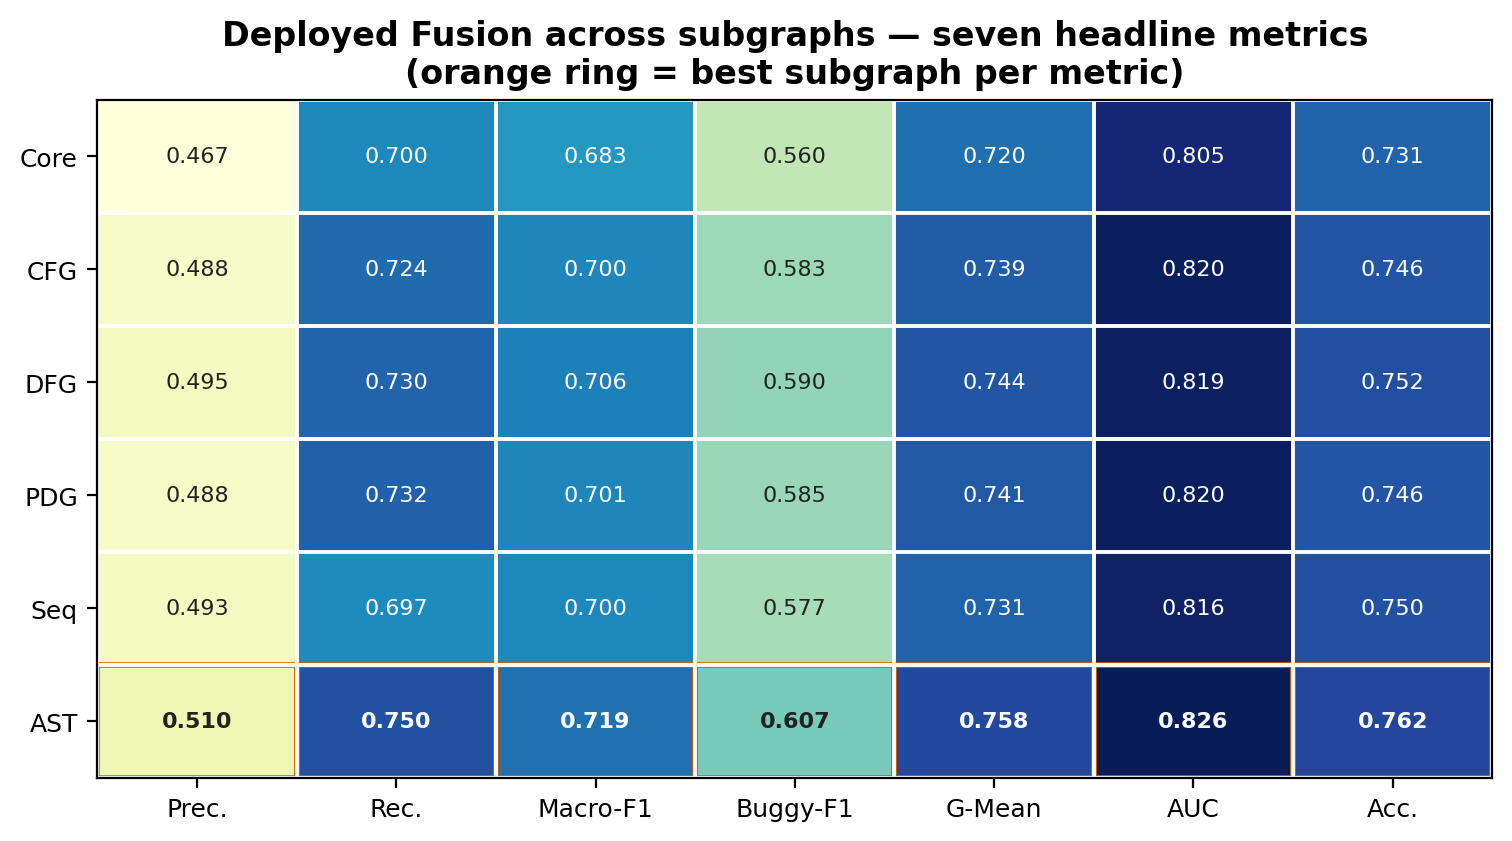

In [8]:
M7 = [("Precision","Prec."),("Recall","Rec."),("Macro_F1","Macro-F1"),
      ("Buggy_F1","Buggy-F1"),("G_Mean","G-Mean"),("AUC","AUC"),("ACC","Acc.")]
fus7 = pd.DataFrame({lbl:{NAME[v]:res[v]["methods"]["Fusion"][mk] for v in ORDER}
                     for mk,lbl in M7}).loc[[NAME[v] for v in ORDER]]
display(fus7.style.format("{:.3f}").highlight_max(axis=0, color="#d5efdf")
        .set_caption("Fusion (M+T+R+P) across subgraphs — seven headline metrics"))
display(Image(filename=str(FIG / "fig_metrics_fusion.png")))

### Online-evaluation trend per metric (stream plots)

For each headline metric we plot the **rolling prequential value against the commit
index** in the chronological stream (window = 800 commits), one line per subgraph
(deployed Fusion). This is the streaming/online view of the comparison: it shows
not just the end-of-stream number but how each subgraph tracks over time. **AST
(bold) leads or ties at essentially every point on every metric**, and **Core
(dashed) trails throughout**; the ordering is preserved through the mid-stream
peak and the late-stream concept drift.

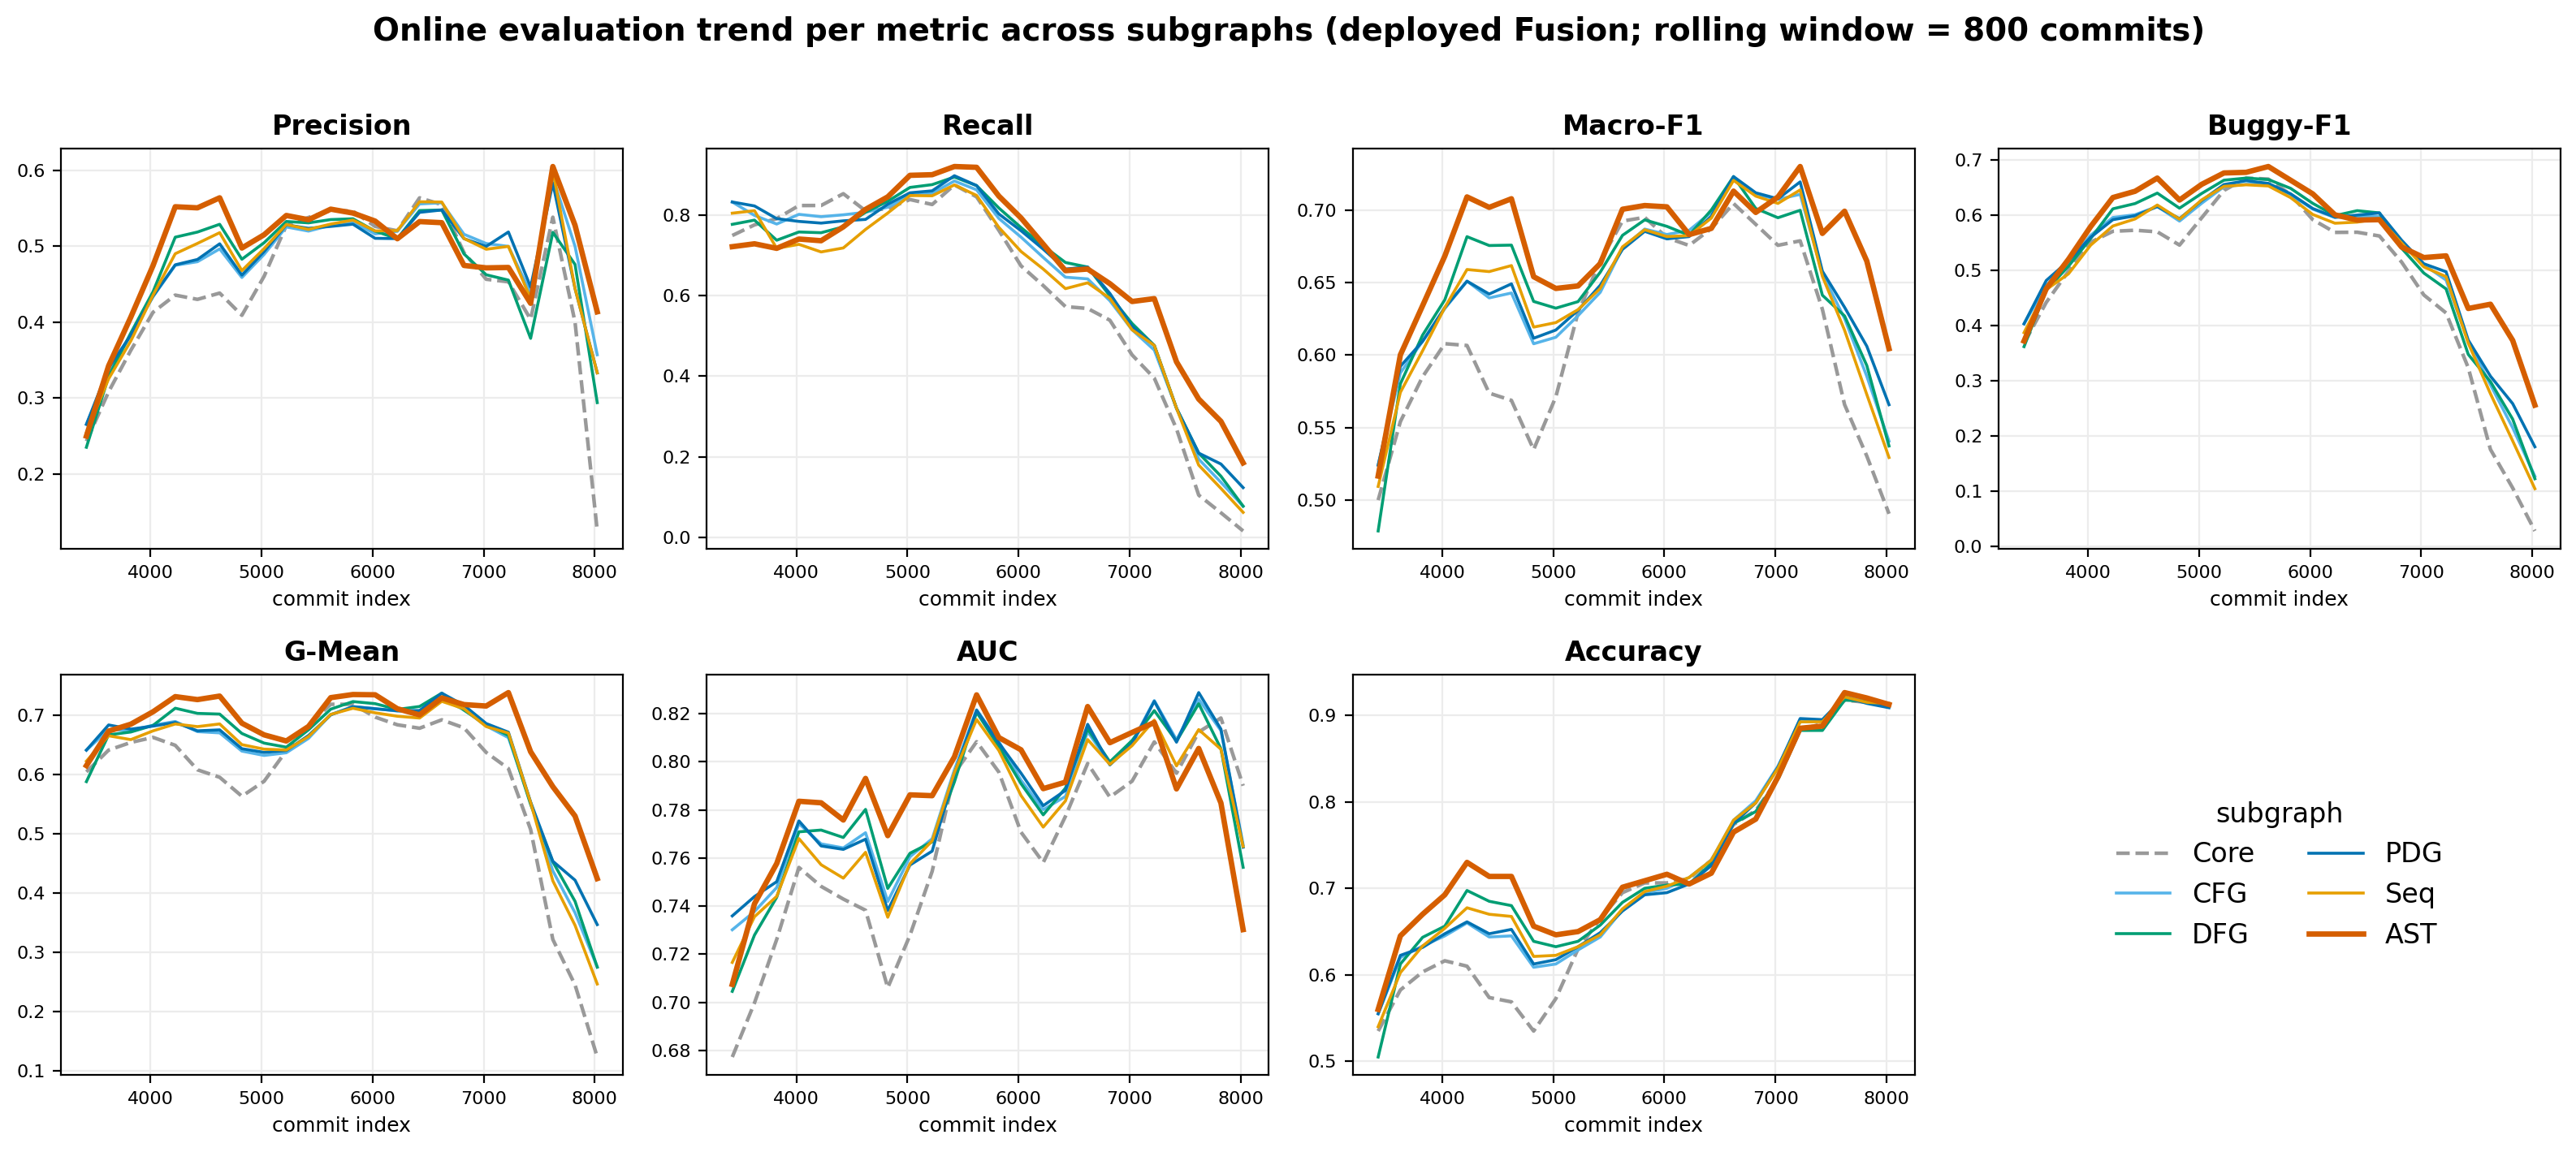

In [9]:
display(Image(filename=str(FIG / "fig_metric_streams.png")))

## 6. Five graph-native online KG-inference methods

The methods above mix graph and non-graph signals (M is tabular; Fusion blends
M+R). We therefore add **five purely graph-native, online KG-inference methods**,
each run on **two graph scopes** so the subgraph's contribution is not confounded
by the shared file/developer relational layer:

| method | family | graph-pure? |
|---|---|---|
| **RN** relational neighbour (wvRN) | collective classification | yes |
| **PPR** Personalized PageRank / RWR | random walk | yes |
| **LP** label propagation | spreading activation | yes |
| **DW** DeepWalk embedding (PPMI+SVD) | random-walk embedding | yes |
| **KGE** DistMult on (commit,rel,hub) triples | KG embedding | yes |

* **scope = subgraph** — commits linked only to their change-token hubs (the graph
  the structural subgraph actually defines);
* **scope = full** — commits linked to token **+ file + developer** hubs (deployed
  heterogeneous graph).

These are **added alongside** the originals — nothing is removed.

In [10]:
import pickle as _pk
KGP = OUT / "subgraph_kg_methods_results.pkl"
kg = _pk.load(open(KGP,"rb")) if KGP.exists() else None
KG_ORDER=["RN","PPR","LP","DW","KGE"]
KGN={"RN":"Relational neighbour","PPR":"PageRank RWR","LP":"Label propagation",
     "DW":"DeepWalk embed","KGE":"KG embed DistMult"}
if kg:
    # all methods (original + graph-native, both scopes) x 7 metrics, at AST
    recs=[(f"{m}",res["V3_ast"]["methods"][m]) for m in ["M","R","T","P","E","Fusion"]]
    for sc in ("subgraph","full"):
        for m in KG_ORDER: recs.append((f"{KGN[m]} [{sc}]", kg["V3_ast"][sc][m]))
    allm=pd.DataFrame({lbl:{n:r[mk] for n,r in recs} for mk,lbl in M7}).loc[[n for n,_ in recs]]
    display(allm.style.format("{:.3f}").highlight_max(axis=0,color="#d5efdf")
            .set_caption("All inference methods on the AST subgraph — seven metrics"))

,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M,0.303,0.840,0.484,0.445,0.559,0.679,0.487
R,0.360,0.809,0.583,0.498,0.656,0.733,0.600
T,0.402,0.727,0.632,0.518,0.687,0.751,0.668
P,0.361,0.819,0.584,0.501,0.658,0.707,0.600
E,0.365,0.739,0.594,0.489,0.657,0.692,0.621
Fusion,0.510,0.750,0.719,0.607,0.758,0.826,0.762
Relational neighbour [subgraph],0.301,0.906,0.460,0.452,0.535,0.638,0.461
PageRank RWR [subgraph],0.312,0.859,0.498,0.458,0.575,0.632,0.501
Label propagation [subgraph],0.289,0.900,0.432,0.437,0.502,0.592,0.432
DeepWalk embed [subgraph],0.370,0.732,0.599,0.492,0.660,0.709,0.629


**Heatmap** of every method × 7 metrics at AST, and the five graph-native methods across subgraphs (Buggy-F1, both scopes):

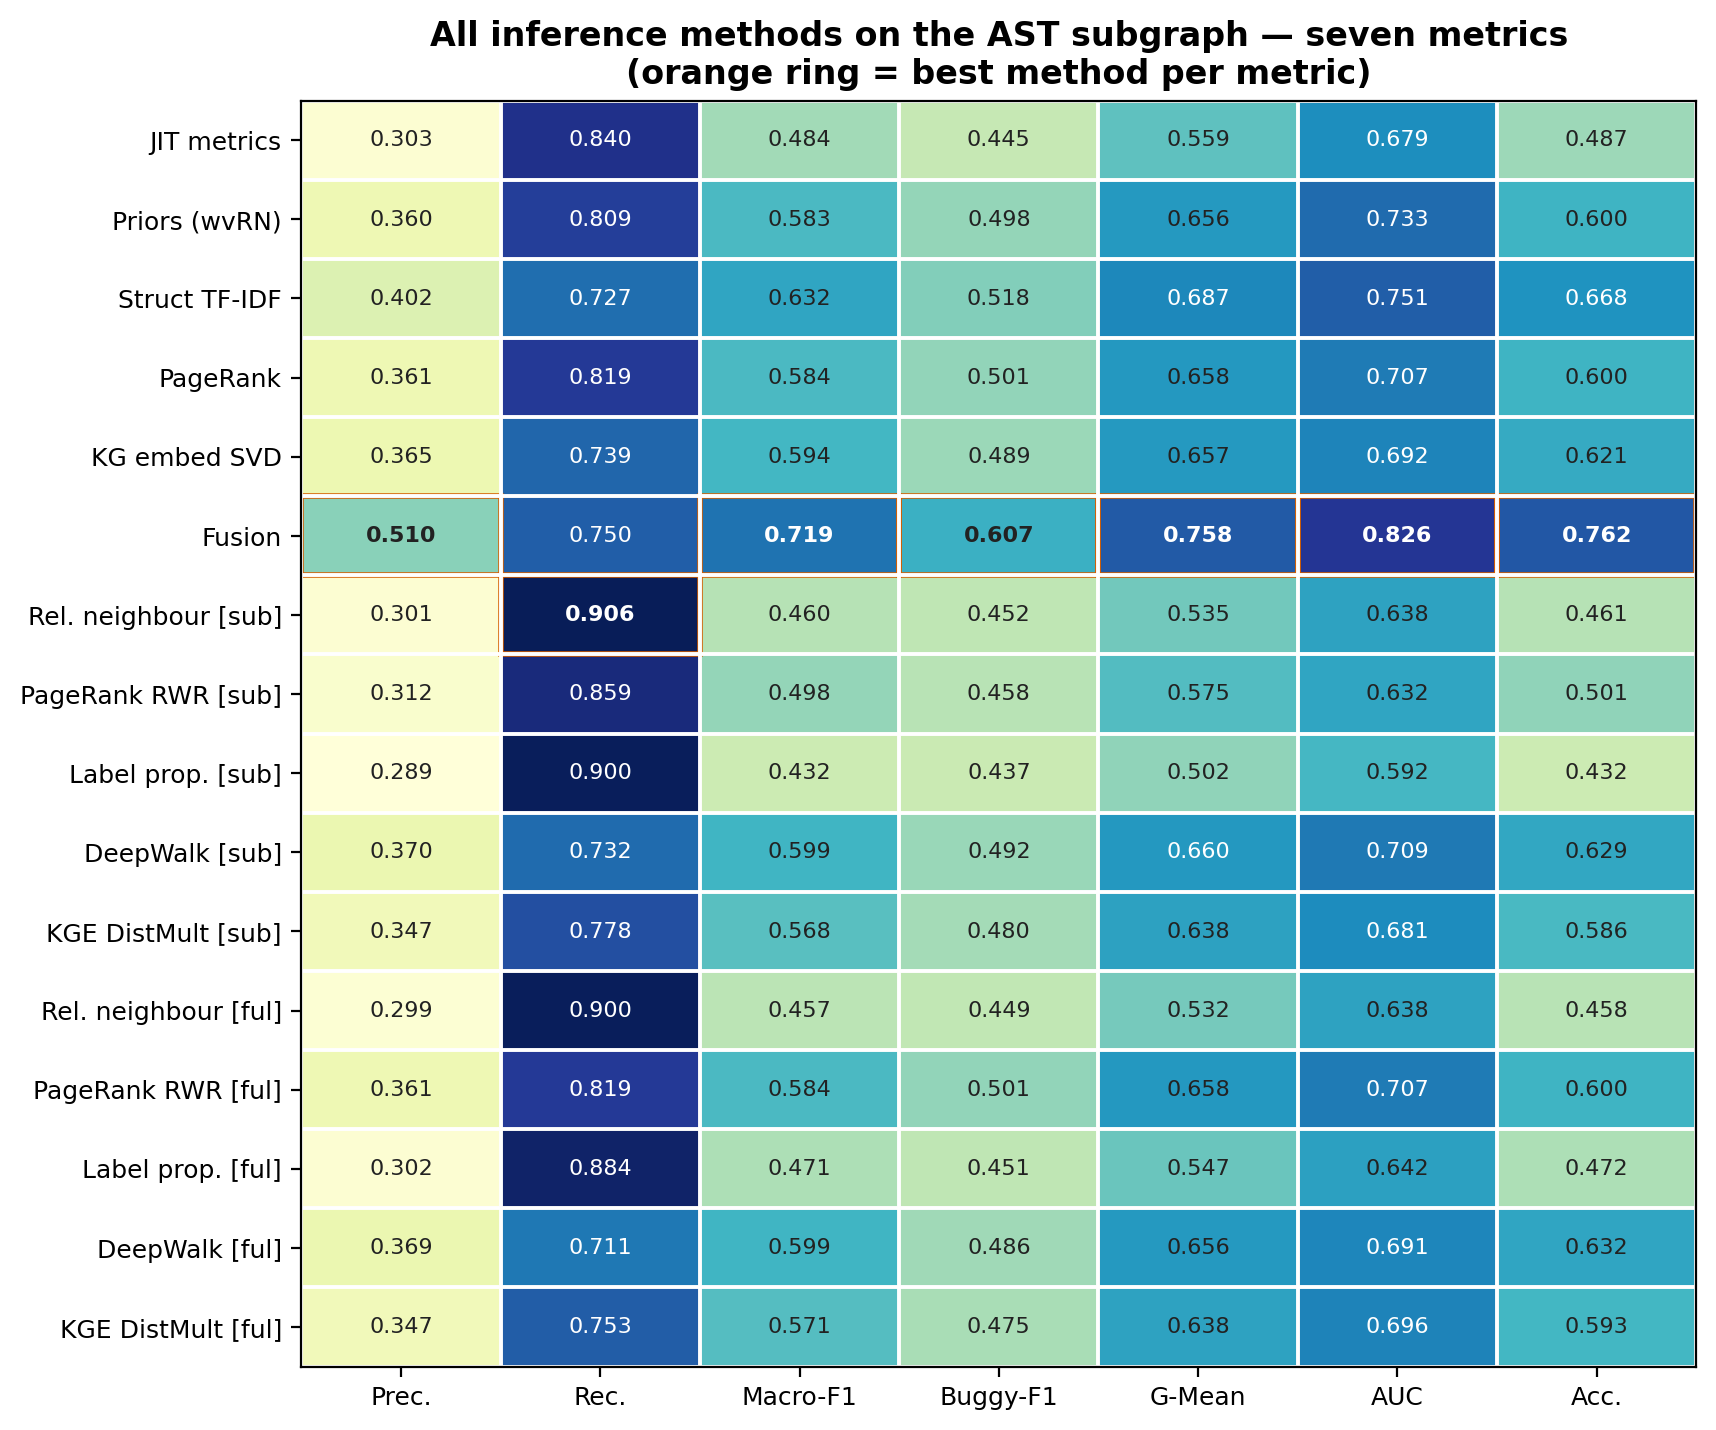

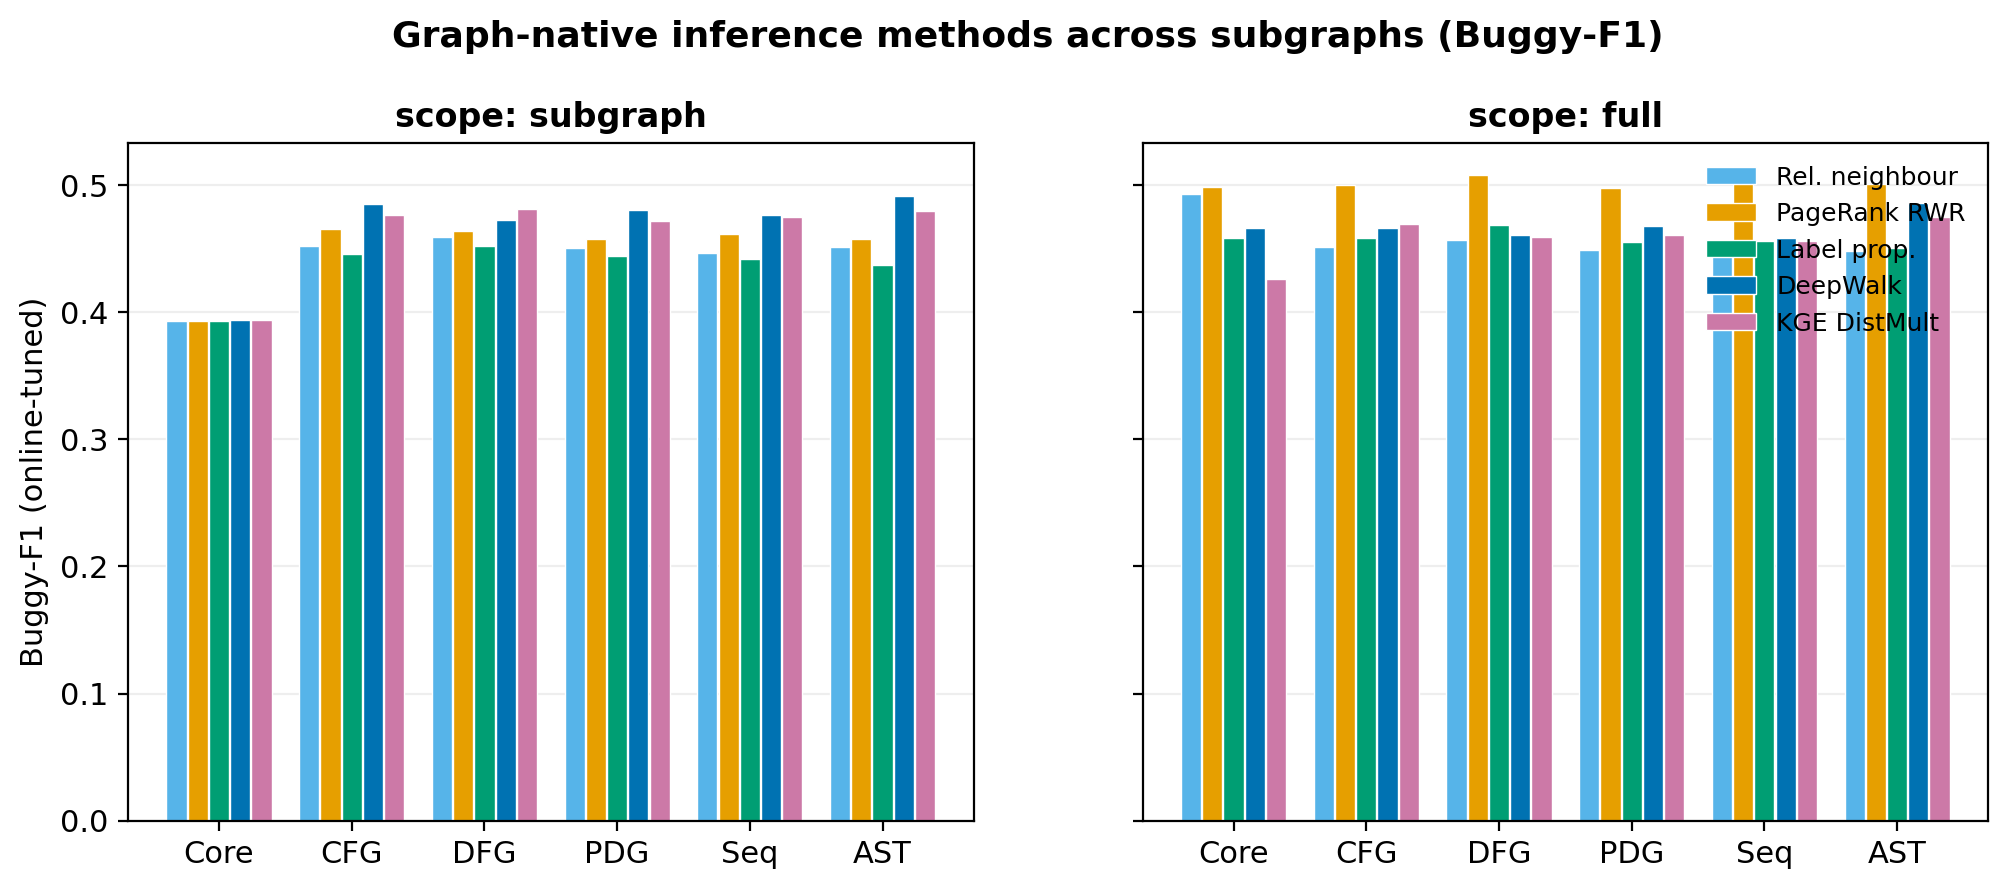

In [11]:
display(Image(filename=str(FIG / "fig_metrics_allmethods.png")))
if kg: display(Image(filename=str(FIG / "fig_kg_methods_bf1.png")))

### What the graph-native methods show

* **Two regimes.** The random-walk / propagation methods (**RN, PPR, LP**) are
  strongest on the *core / full* relational graph and are diluted by structural
  tokens — their signal is relational (file/developer), not structural. The
  **embedding** methods (**DW DeepWalk, KGE DistMult**) instead prefer the
  token-rich subgraphs and rank **AST** highest among them, echoing the TF-IDF
  result.
* On the AST subgraph, **Fusion still dominates the balanced metrics**
  (Macro-F1, Buggy-F1, G-Mean, AUC, Accuracy); the pure relational methods reach
  very high **Recall** at the cost of Precision (they flag buggy liberally).
* Reporting **both scopes** cleanly separates "what the subgraph adds" (subgraph
  scope) from "what the deployed heterogeneous graph achieves" (full scope),
  removing the file/developer confound identified in the audit.

## 7. Choosing the final Fusion — comprehensive ablation

To choose a defensible final Fusion formula we ablate **all combinations** of ten
inference methods on the **final graph (Core + AST + CSTG, no X)**: previous
M, R, T, P, E, G(CSTG) and new RN, LP, DW, KGE. Two fusion styles are compared —
**score stacking** (prequential LR over the selected methods' probabilities; all
$2^{10}-1=1023$ subsets) and **feature fusion** (concatenated raw blocks of the top
channels; all $2^6-1=63$ subsets). All seven metrics, online-tuned operating point
(`inference/run_fusion_ablation.py`).

In [12]:
import pickle as _pk
FA = _pk.load(open(OUT / "fusion_ablation_results.pkl", "rb"))
M7L = [("Precision","Prec."),("Recall","Rec."),("Macro_F1","Macro-F1"),
       ("Buggy_F1","Buggy-F1"),("G_Mean","G-Mean"),("AUC","AUC"),("ACC","Acc.")]
# singles ranked
sing = sorted([v for v in FA["stack"].values() if len(v["methods"])==1],
              key=lambda v:-v["Buggy_F1"])
sdf = pd.DataFrame([{"method":v["methods"][0], "graph":"yes" if v["graph_only"] else "no",
                     **{lbl:v[mk] for mk,lbl in M7L}} for v in sing])
display(sdf.style.hide(axis="index").format({l:"{:.3f}" for _,l in M7L})
        .set_caption("Single methods on the final graph (ranked by Buggy-F1): "
                     "CSTG (G) is strongest, non-graph M is near the weakest"))

method,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
G,yes,0.517,0.702,0.716,0.596,0.743,0.824,0.766
T,yes,0.418,0.710,0.646,0.526,0.694,0.759,0.687
P,yes,0.374,0.815,0.600,0.512,0.673,0.720,0.619
R,yes,0.388,0.752,0.618,0.512,0.680,0.746,0.648
KGE,yes,0.381,0.754,0.611,0.506,0.674,0.727,0.639
DW,yes,0.401,0.664,0.629,0.500,0.671,0.716,0.674
LP,yes,0.340,0.914,0.540,0.496,0.623,0.711,0.545
E,yes,0.425,0.579,0.641,0.490,0.657,0.716,0.705
M,no,0.346,0.765,0.568,0.476,0.636,0.701,0.587
RN,yes,0.317,0.901,0.498,0.469,0.577,0.652,0.500


**Best combinations and the recommended formula** (feature-fusion unless noted). Performance saturates by ~3–4 components; a compact **graph-only R+T+G** matches the best while dropping non-graph M:

fusion,graph,#ch,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+T+R+P (previous),no,4,0.519,0.690,0.715,0.593,0.739,0.820,0.767
M+R+T+G (best overall),no,4,0.541,0.727,0.734,0.620,0.762,0.832,0.782
R+T+P+G+RN+LP+KGE (best graph stack),yes,7,0.549,0.708,0.735,0.618,0.758,0.843,0.786
R+T+P+G,yes,4,0.506,0.745,0.715,0.603,0.755,0.834,0.759
T+G,yes,2,0.495,0.768,0.711,0.602,0.757,0.827,0.751
R+T+G (RECOMMENDED),yes,3,0.504,0.768,0.716,0.608,0.761,0.834,0.758


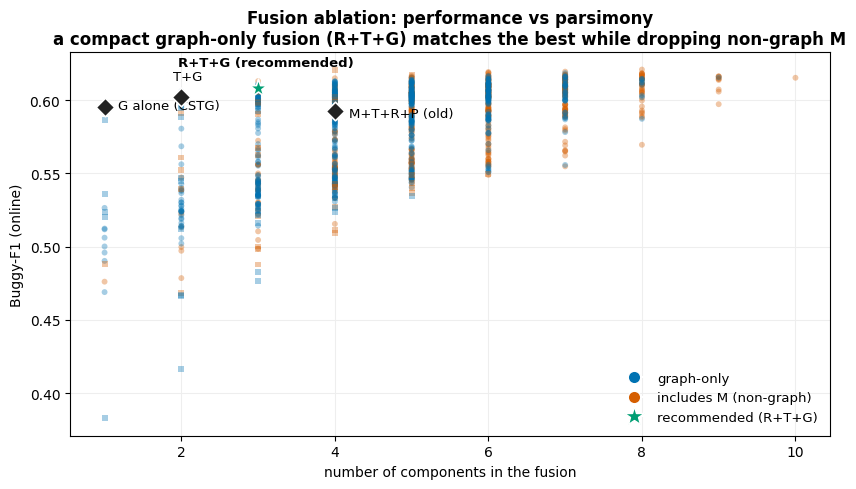

In [13]:
def _find(fam, ms):
    s=set(ms)
    return next((v for v in FA[fam].values() if set(v["methods"])==s), None)
picks=[("feat",["M","T","R","P"],"M+T+R+P (previous)"),
       ("feat",["M","R","T","G"],"M+R+T+G (best overall)"),
       ("stack",["R","T","P","G","RN","LP","KGE"],"R+T+P+G+RN+LP+KGE (best graph stack)"),
       ("feat",["R","T","P","G"],"R+T+P+G"),
       ("feat",["T","G"],"T+G"),
       ("feat",["R","T","G"],"R+T+G  (RECOMMENDED)")]
rows=[]
for fam,ms,name in picks:
    v=_find(fam,ms)
    if v: rows.append({"fusion":name,"graph":"yes" if v["graph_only"] else "no",
                       "#ch":len(v["methods"]),**{lbl:v[mk] for mk,lbl in M7L}})
fdf=pd.DataFrame(rows)
display(fdf.style.hide(axis="index").format({l:"{:.3f}" for _,l in M7L})
        .set_caption("Candidate final Fusion formulas x 7 metrics"))
display(Image(filename=str(FIG / "fig_fusion_pareto.png")))

### Recommended final Fusion: **R + T + G** (graph-only)

- **R** relational priors + **T** AST structural change-tokens + **G** CSTG
  semantic-text — three interpretable, purely graph-native channels.
- vs the previous metrics-inclusive **M+T+R+P**, R+T+G improves the minority-class
  metrics — **Recall 0.768 (+0.078), Buggy-F1 0.608 (+0.016), G-Mean 0.761 (+0.022),
  AUC 0.834 (+0.014), Macro-F1 0.716 (+0.002)** — with tiny trades on Precision
  (−0.015) and Accuracy (−0.010), i.e. a healthier recall-oriented operating point
  for the minority buggy class.
- It **drops the non-graph JIT metrics (M)** — which the singles show is the
  *weakest* channel — and is **simpler** (3 vs 4 components).
- **G (CSTG) is the single most valuable channel** (Buggy-F1 0.596 alone), and
  larger fusions (up to 7 graph methods, Buggy-F1 0.618) add only marginal gains
  over R+T+G — so R+T+G is the parsimonious, defensible choice for a Q1 paper.

**Conclusion:** adopt **Fusion = R + T + G** as the deployed, purely graph-native
model; report the full ablation (tables + Pareto plot above) as justification.

### Full ablation — best fusions at every size

The complete ablation has $2^{10}-1=1023$ score-stacking combinations. We show, for
each fusion size $k=1,\dots,10$, the **best 8 $k$-method fusions** by Buggy-F1 (the
$k{=}10$ table has the single all-methods combination), on all seven metrics —
followed by three aggregate visualizations.

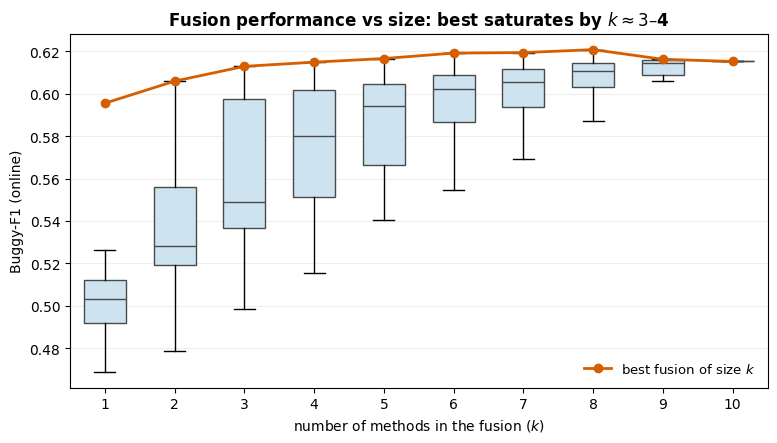

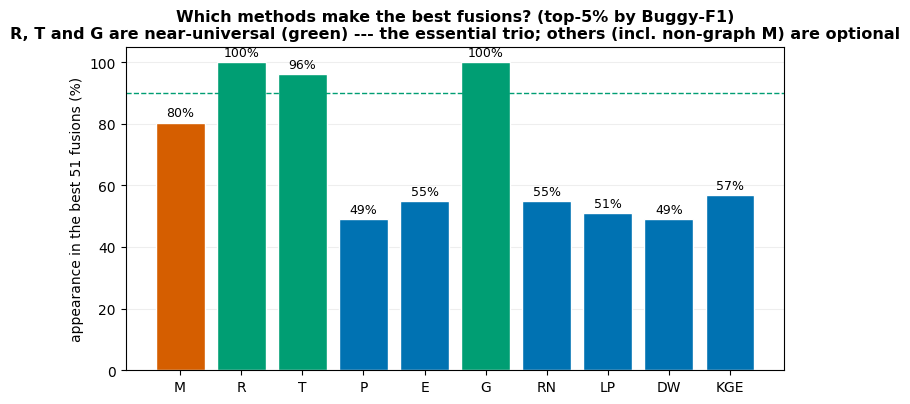

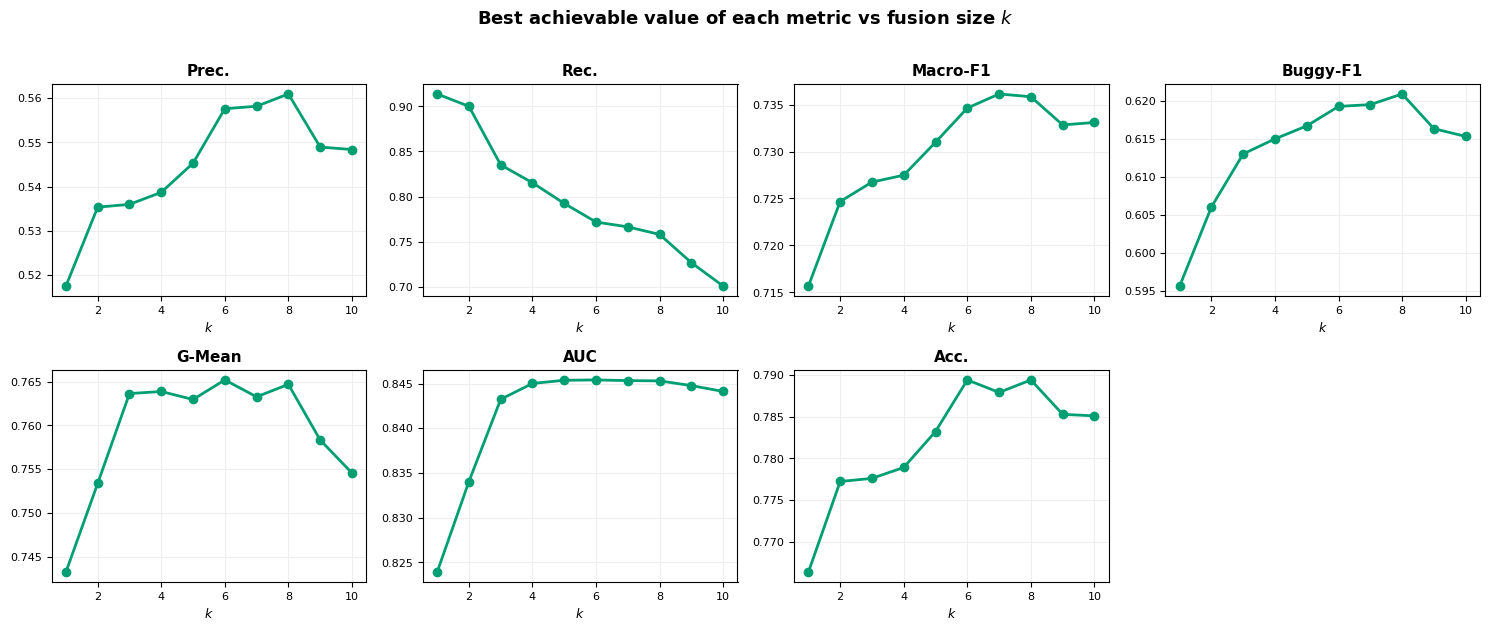

In [14]:
display(Image(filename=str(FIG / "fig_ablation_bysize.png")))
display(Image(filename=str(FIG / "fig_ablation_method_freq.png")))
display(Image(filename=str(FIG / "fig_ablation_bestperk.png")))

In [15]:
# 10 per-size tables: top-8 by Buggy-F1, all seven metrics
stack = list(FA["stack"].values())
for k in range(1, 11):
    subs = sorted([v for v in stack if len(v["methods"])==k], key=lambda v:-v["Buggy_F1"])[:8]
    tdf = pd.DataFrame([{"fusion":"+".join(v["methods"]), "graph":"yes" if v["graph_only"] else "no",
                         **{lbl:v[mk] for mk,lbl in M7L}} for v in subs])
    sty = (tdf.style.hide(axis="index").format({l:"{:.3f}" for _,l in M7L})
           .set_caption(f"k={k}: best {len(subs)} fusion(s) of {k} method(s) by Buggy-F1")
           .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","110%")]}]))
    display(sty)

fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
G,yes,0.517,0.702,0.716,0.596,0.743,0.824,0.766
T,yes,0.418,0.710,0.646,0.526,0.694,0.759,0.687
P,yes,0.374,0.815,0.600,0.512,0.673,0.720,0.619
R,yes,0.388,0.752,0.618,0.512,0.680,0.746,0.648
KGE,yes,0.381,0.754,0.611,0.506,0.674,0.727,0.639
DW,yes,0.401,0.664,0.629,0.500,0.671,0.716,0.674
LP,yes,0.340,0.914,0.540,0.496,0.623,0.711,0.545
E,yes,0.425,0.579,0.641,0.490,0.657,0.716,0.705


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
R+G,yes,0.521,0.724,0.721,0.606,0.753,0.833,0.769
G+KGE,yes,0.535,0.694,0.725,0.604,0.747,0.833,0.777
T+G,yes,0.517,0.715,0.718,0.600,0.748,0.834,0.766
P+G,yes,0.509,0.731,0.715,0.600,0.751,0.829,0.761
G+LP,yes,0.521,0.707,0.719,0.600,0.747,0.828,0.769
M+G,no,0.509,0.725,0.714,0.598,0.749,0.826,0.761
G+DW,yes,0.515,0.713,0.716,0.598,0.747,0.828,0.765
G+RN,yes,0.520,0.701,0.717,0.597,0.744,0.827,0.768


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+G,no,0.512,0.764,0.721,0.613,0.764,0.836,0.763
R+G+RN,yes,0.532,0.718,0.727,0.611,0.755,0.834,0.776
R+G+KGE,yes,0.525,0.729,0.725,0.610,0.757,0.839,0.772
R+T+G,yes,0.525,0.727,0.724,0.610,0.756,0.843,0.772
P+G+KGE,yes,0.530,0.712,0.725,0.608,0.753,0.835,0.775
R+G+LP,yes,0.518,0.734,0.721,0.608,0.756,0.834,0.768
R+E+G,yes,0.531,0.711,0.725,0.608,0.752,0.837,0.775
M+T+G,no,0.513,0.741,0.719,0.606,0.756,0.835,0.764


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+G,no,0.518,0.756,0.724,0.615,0.764,0.845,0.768
R+T+G+RN,yes,0.531,0.724,0.727,0.613,0.758,0.843,0.776
R+T+G+DW,yes,0.519,0.747,0.724,0.613,0.761,0.843,0.768
R+T+P+G,yes,0.530,0.726,0.727,0.612,0.758,0.843,0.775
R+G+RN+KGE,yes,0.532,0.720,0.727,0.612,0.756,0.840,0.776
R+T+G+KGE,yes,0.531,0.721,0.727,0.611,0.756,0.843,0.775
R+G+RN+LP,yes,0.529,0.724,0.726,0.611,0.757,0.834,0.774
M+R+G+RN,no,0.512,0.756,0.721,0.611,0.761,0.837,0.764


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+G+DW,no,0.531,0.734,0.729,0.617,0.762,0.845,0.776
M+R+T+G+RN,no,0.524,0.746,0.727,0.616,0.763,0.845,0.772
R+T+G+RN+KGE,yes,0.539,0.717,0.731,0.616,0.758,0.843,0.780
M+R+T+G+KGE,no,0.527,0.740,0.727,0.615,0.762,0.845,0.773
M+R+T+E+G,no,0.522,0.750,0.726,0.615,0.763,0.845,0.770
M+R+T+P+G,no,0.532,0.727,0.729,0.615,0.759,0.845,0.776
M+R+T+G+LP,no,0.522,0.746,0.725,0.614,0.762,0.845,0.770
R+G+RN+LP+KGE,yes,0.537,0.716,0.730,0.614,0.757,0.840,0.779


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+G+RN+DW,no,0.529,0.747,0.730,0.619,0.765,0.845,0.775
M+R+T+E+G+DW,no,0.529,0.744,0.730,0.619,0.764,0.844,0.775
M+R+T+E+G+KGE,no,0.542,0.719,0.733,0.618,0.760,0.845,0.782
M+R+T+G+RN+LP,no,0.527,0.744,0.728,0.617,0.763,0.845,0.774
M+R+T+P+G+RN,no,0.533,0.731,0.730,0.617,0.761,0.845,0.777
R+T+P+G+RN+KGE,yes,0.542,0.715,0.732,0.616,0.758,0.843,0.782
R+T+G+RN+LP+KGE,yes,0.540,0.718,0.731,0.616,0.758,0.843,0.781
M+R+T+G+LP+DW,no,0.529,0.736,0.728,0.616,0.761,0.845,0.775


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+P+E+G+KGE,no,0.553,0.705,0.736,0.619,0.758,0.844,0.788
R+T+P+G+RN+LP+KGE,yes,0.549,0.708,0.735,0.618,0.758,0.843,0.786
M+R+T+G+RN+LP+DW,no,0.529,0.741,0.729,0.618,0.763,0.845,0.775
M+R+T+P+G+LP+KGE,no,0.534,0.732,0.730,0.617,0.762,0.845,0.777
M+R+T+P+G+RN+DW,no,0.542,0.717,0.732,0.617,0.759,0.845,0.782
M+R+E+G+RN+LP+KGE,no,0.537,0.724,0.731,0.617,0.760,0.843,0.779
M+R+T+P+G+RN+KGE,no,0.536,0.725,0.730,0.616,0.760,0.845,0.779
R+T+P+G+LP+DW+KGE,yes,0.543,0.712,0.732,0.616,0.757,0.842,0.782


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+P+G+RN+LP+DW,no,0.536,0.738,0.732,0.621,0.765,0.845,0.779
M+R+T+P+E+G+RN+KGE,no,0.554,0.700,0.736,0.618,0.756,0.845,0.788
M+R+T+P+E+G+LP+KGE,no,0.554,0.700,0.736,0.618,0.756,0.845,0.788
M+R+T+P+E+G+LP+DW,no,0.542,0.718,0.733,0.618,0.759,0.844,0.782
M+R+T+E+G+RN+LP+DW,no,0.535,0.731,0.731,0.618,0.762,0.844,0.778
M+R+T+E+G+LP+DW+KGE,no,0.544,0.712,0.733,0.617,0.758,0.844,0.783
M+R+T+E+G+RN+LP+KGE,no,0.542,0.715,0.732,0.617,0.758,0.845,0.782
M+R+T+G+RN+LP+DW+KGE,no,0.536,0.726,0.730,0.617,0.760,0.845,0.779


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+P+E+G+RN+LP+DW,no,0.543,0.713,0.732,0.616,0.758,0.844,0.782
M+R+T+P+E+G+RN+DW+KGE,no,0.542,0.713,0.732,0.616,0.757,0.844,0.782
M+R+T+E+G+RN+LP+DW+KGE,no,0.540,0.718,0.731,0.616,0.758,0.844,0.781
R+T+P+E+G+RN+LP+DW+KGE,yes,0.547,0.704,0.733,0.615,0.755,0.842,0.784
M+R+T+P+E+G+LP+DW+KGE,no,0.546,0.704,0.732,0.615,0.755,0.844,0.784
M+R+T+P+E+G+RN+LP+KGE,no,0.549,0.698,0.733,0.614,0.753,0.845,0.785
M+R+T+P+G+RN+LP+DW+KGE,no,0.532,0.726,0.728,0.614,0.758,0.845,0.776
M+T+P+E+G+RN+LP+DW+KGE,no,0.528,0.715,0.724,0.607,0.753,0.838,0.773


fusion,graph,Prec.,Rec.,Macro-F1,Buggy-F1,G-Mean,AUC,Acc.
M+R+T+P+E+G+RN+LP+DW+KGE,no,0.548,0.701,0.733,0.615,0.755,0.844,0.785


## 8. Findings (subgraph RQ)

1. **AST is the best structural subgraph on every metric** — Fusion PR-AUC
   **0.615**, ROC-AUC **0.826**, F1-online **0.607** — ahead of the best
   alternative (CFG/PDG, 0.595 PR-AUC) and well ahead of the core-only floor
   (0.564).
2. **Every subgraph beats core-only** (PR-AUC 0.587–0.595 vs 0.564): structural
   change information is genuinely informative for JIT defect prediction.
3. **The alternatives cluster tightly and below AST.** CFG ≈ PDG ≈ DFG; the
   deliberately weak token-sequence layer is lowest of the four — exactly the
   expected ordering.
4. **Mechanism.** Isolating the structural tokens (T-only PR-AUC) ranks
   AST 0.488 > DFG 0.469 > PDG 0.464 > CFG 0.461 > Token-seq 0.432 > core 0.204,
   and this tracks **token-vocabulary richness** (AST 314 distinct change-token
   types vs 27–63 for the others). AST's fine-grained typing captures *which kind*
   of code element changed at a resolution the coarser statement-level graphs
   cannot.
5. **Consistency.** The rolling-window trajectory shows AST leading at every point
   in the chronological stream; the ranking is preserved through concept drift.

**Conclusion.** Under a fair, identical online protocol with text and the
semantic-text subgraph disabled, the **AST delta-subgraph is the strongest
structural layer** for the KG — justifying its choice as the methodology's
structural representation before the CSTG layer is introduced.


## 9. Reproduce
```bash
# build each alternative layer (resumable; indexes auto-created)
python build_subgraph_online_kg.py --kind cfg   # dfg | pdg | seq
python validate_subgraph_kg.py    --kind cfg --recheck 15 --samples 10
# evaluate (original + graph-native methods) + tables + figures
python inference/run_subgraph_rq.py            # M,R,T,P,E,Fusion (7 metrics)
python inference/run_kg_methods_rq.py          # RN,PPR,LP,DW,KGE (both scopes)
python inference/collect_subgraph_stats.py
python inference/make_subgraph_tables.py       # structural tables
python inference/make_metrics_tables.py        # 7-metric tables (all methods)
python inference/make_subgraph_figures.py
python inference/make_metrics_figures.py
# final-method fusion ablation (choose R+T+G) + report
python inference/run_fusion_ablation.py
python inference/make_fusion_ablation_report.py
```
